In [1]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import textwrap
from pathlib import Path
from collections import Counter
from typing import Dict, Optional, List, Any

# --- CONFIGURAÇÕES ---
# Diretório onde os arquivos CSV do CNES estão localizados
DATA_DIR = Path('CNES/')
# Período (AnoMês) para análise
PERIODO = '202507'
# Diretório para salvar os dashboards gerados
OUTPUT_DIR = Path('dashboards/')
# Encoding padrão dos arquivos do DATASUS
ENCODING = 'latin-1'

# --- CONFIGURAÇÕES DE VISUALIZAÇÃO ---
warnings.filterwarnings('ignore')
plt.style.use("dark_background")
sns.set_theme(style="darkgrid", palette="mako")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [3]:
arquivos_csv = glob.glob('CNES/' + '*.csv')

# Anos que vão ser utilizados para a análise e quantidade de tabelas
print(Counter([f"Ano: {arquivo[-10:-6]} - Mês: {arquivo[-6:-4]}" for arquivo in arquivos_csv]))

Counter({'Ano: 2025 - Mês: 07': 108, 'Ano: 2025 - Mês: 06': 108, 'Ano: 2025 - Mês: 05': 108, 'Ano: 2017 - Mês: 01': 108})


In [ ]:
def processar_tabelas(diretorio: Path, periodo: str) -> Dict[str, pd.DataFrame]:
    """
    Carrega todos os arquivos CSV de um determinado período de um diretório
    para um dicionário de DataFrames do Pandas.
    """
    dfs = {}
    arquivos_csv = list(diretorio.glob(f'*{periodo}.csv'))
    print(f"Encontrados {len(arquivos_csv)} arquivos para o período {periodo}.\n")

    for arquivo_path in arquivos_csv:
        # Extrai o nome da tabela do nome do arquivo (ex: 'tbEstabelecimento')
        nome_tabela = arquivo_path.name.replace(periodo, '').replace('.csv', '')
        try:
            df = pd.read_csv(arquivo_path, sep=';', encoding=ENCODING, low_memory=False)

            if df.empty:
                print(f"⚠️  Tabela '{nome_tabela}' ({arquivo_path.name}) está vazia.")
                continue

            # Limpeza básica
            df = df.replace({'': pd.NA, ' ': pd.NA})
            dfs[nome_tabela] = df
            print(f"✅ Tabela '{nome_tabela}' carregada: {df.shape}")

        except Exception as e:
            print(f"❌ Erro ao processar '{arquivo_path.name}': {e}")

    return dfs

# Carrega os dados
dfs = processar_tabelas(DATA_DIR, PERIODO)
print(f"\nTotal de tabelas carregadas: {len(dfs)}")

Encontrados 108 arquivos para o período 202507.

✅ Tabela 'tbConvenio' carregada: (7, 2)
✅ Tabela 'rlMunRegimeRes' carregada: (97, 5)
✅ Tabela 'tbDadosProfissionalSus' carregada: (7341502, 11)
⚠️  Tabela 'rlEstabEquipeMun' (rlEstabEquipeMun202507.csv) está vazia.
✅ Tabela 'tbMotivoDesativEquipe' carregada: (16, 2)
✅ Tabela 'tbAvaliacao' carregada: (8, 2)
✅ Tabela 'tbSubtipoInstalacao' carregada: (7, 2)
✅ Tabela 'rlEstabSipac' carregada: (113967, 9)
✅ Tabela 'tbEtnia' carregada: (264, 2)
✅ Tabela 'tbConselhoClasse' carregada: (12, 2)
✅ Tabela 'tbHemoterapia' carregada: (2310, 45)
⚠️  Tabela 'tbEstabContrato' (tbEstabContrato202507.csv) está vazia.
✅ Tabela 'tbTpModVinculo' carregada: (39, 3)
✅ Tabela 'tbTipoAbrangencia' carregada: (6, 2)
✅ Tabela 'tbAtividadeEnsino' carregada: (5, 2)
✅ Tabela 'tbResidenciaMed' carregada: (1300, 27)
✅ Tabela 'tbAtividadeProfissional' carregada: (2737, 6)
✅ Tabela 'tbServicoApoio' carregada: (12, 2)
✅ Tabela 'tbTipoEqSubTipo' carregada: (56, 2)
✅ Tabela '

In [5]:
# Este dicionário centraliza as informações sobre as chaves das tabelas.
# É um passo crucial para análises de relacionamento e uso com frameworks como Relbench.
SCHEMA_CNES = {
    'tbEstabelecimento': {
        'pkey': 'CO_UNIDADE',
        'fkeys': {},
        'description': 'Tabela principal de estabelecimentos de saúde.'
    },
    'rlEstabComplementar': {
        'pkey': ['CO_UNIDADE', 'CO_LEITO'], # Chave Composta
        'fkeys': {'CO_UNIDADE': 'tbEstabelecimento'},
        'description': 'Relaciona estabelecimentos com seus leitos hospitalares.'
    },
    'rlEstabAtendPrestConv': {
        'pkey': None, # Tabela de relacionamento sem chave primária clara
        'fkeys': {'CO_UNIDADE': 'tbEstabelecimento'},
        'description': 'Atendimentos prestados por convênio em cada unidade.'
    },
    'rlEstabProgFundo': {
        'pkey': None,
        'fkeys': {'CO_UNIDADE': 'tbEstabelecimento'},
        'description': 'Programas e fundos associados a cada unidade.'
    },
    'rlEstabColetaSelRejeito': {
        'pkey': None,
        'fkeys': {'CO_UNIDADE': 'tbEstabelecimento'},
        'description': 'Tipos de coleta de rejeitos por unidade.'
    },
    'rlEstabServicoApoio': {
        'pkey': None,
        'fkeys': {'CO_UNIDADE': 'tbEstabelecimento'},
        'description': 'Serviços de apoio (diagnóstico, terapia) por unidade.'
    },
    'tbDialise': {
        'pkey': 'CO_UNIDADE',
        'fkeys': {'CO_UNIDADE': 'tbEstabelecimento'},
        'description': 'Informações sobre serviços de diálise.'
    },
    'tbQuimioRadio': {
        'pkey': 'CO_UNIDADE',
        'fkeys': {'CO_UNIDADE': 'tbEstabelecimento'},
        'description': 'Informações sobre serviços de quimioterapia e radioterapia.'
    },
    'tbHemoterapia': {
        'pkey': 'CO_UNIDADE',
        'fkeys': {'CO_UNIDADE': 'tbEstabelecimento'},
        'description': 'Informações sobre serviços de hemoterapia.'
    },
    'tbArea': {
        'pkey': ['CO_MUNICIPIO', 'CO_AREA'],
        'fkeys': {'CO_MUNICIPIO': 'tbMunicipio'},
        'description': 'Cadastro de áreas de equipes de saúde.'
    },
    # Adicione outras tabelas importantes aqui
}

print("Schema definido para as seguintes tabelas:")
for nome_tabela in SCHEMA_CNES:
    print(f"- {nome_tabela}: {SCHEMA_CNES[nome_tabela]['description']}")

Schema definido para as seguintes tabelas:
- tbEstabelecimento: Tabela principal de estabelecimentos de saúde.
- rlEstabComplementar: Relaciona estabelecimentos com seus leitos hospitalares.
- rlEstabAtendPrestConv: Atendimentos prestados por convênio em cada unidade.
- rlEstabProgFundo: Programas e fundos associados a cada unidade.
- rlEstabColetaSelRejeito: Tipos de coleta de rejeitos por unidade.
- rlEstabServicoApoio: Serviços de apoio (diagnóstico, terapia) por unidade.
- tbDialise: Informações sobre serviços de diálise.
- tbQuimioRadio: Informações sobre serviços de quimioterapia e radioterapia.
- tbHemoterapia: Informações sobre serviços de hemoterapia.
- tbArea: Cadastro de áreas de equipes de saúde.


In [9]:
def criar_dashboard_tabela(
    df: pd.DataFrame,
    nome_tabela: str,
    save_path: Optional[Path] = None,
    top_n: int = 20,
    figsize: tuple = (30, 30),
    cmap: str = 'mako'
) -> Dict[str, Any]:
    """Cria um dashboard completo e personalizável para análise da tabela."""

    # Métricas
    shape = df.shape
    memory_mb = df.memory_usage(deep=True).sum() / 1024**2
    nulls = df.isnull().sum()
    total_nulls = nulls.sum()
    nulls_pct = (total_nulls / (shape[0] * shape[1]) * 100) if (shape[0] * shape[1]) > 0 else 0
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    # Configuração da Figura
    fig = plt.figure(figsize=figsize)
    fig.suptitle(f'Dashboard de Análise - Tabela: {nome_tabela}', fontsize=20, fontweight='bold')
    grid = plt.GridSpec(4, 3, hspace=0.7, wspace=0.4)

    # Gráfico 1: Tipos de Dados
    ax1 = fig.add_subplot(grid[0, 0])
    tipos_contagem = df.dtypes.value_counts()
    ax1.pie(tipos_contagem, labels=tipos_contagem.index.map(str), autopct='%1.1f%%', startangle=90)
    ax1.set_title('Distribuição de Tipos de Dados', pad=20)

    # Gráfico 2: Valores Nulos
    ax2 = fig.add_subplot(grid[0, 1])
    nulos_top = nulls[nulls > 0].sort_values(ascending=False).head(top_n)
    if not nulos_top.empty:
        sns.barplot(x=nulos_top.values, y=nulos_top.index, ax=ax2, palette="viridis")
        ax2.set_title(f"Top {top_n} Colunas com Valores Nulos", pad=20)
        ax2.set_xlabel("Quantidade de Nulos")
    else:
        ax2.text(0.5, 0.5, 'Sem valores nulos', ha='center', va='center')
        ax2.set_title("Valores Nulos", pad=20)


    # Gráfico 3: Estatísticas de Colunas Numéricas
    ax3 = fig.add_subplot(grid[0, 2])
    if len(numeric_cols) > 0:
        stats = df[numeric_cols].describe().T
        stats_plot = stats[['mean', 'std', 'min', 'max']].head(top_n)
        stats_plot.plot(kind='bar', ax=ax3, colormap="plasma")
        ax3.set_title('Estatísticas (Top N Colunas Numéricas)', pad=20)
        ax3.legend(title='Estatística', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax3.tick_params(axis='x', rotation=45, labelsize=8)
    else:
        ax3.text(0.5, 0.5, 'Não há colunas numéricas', ha='center', va='center')
        ax3.set_title('Estatísticas de Colunas Numéricas', pad=20)

    # Gráfico 4: Valores Únicos (Cardinalidade)
    ax4 = fig.add_subplot(grid[1, 0])
    valores_unicos = df.nunique().sort_values(ascending=False).head(top_n)
    sns.barplot(x=valores_unicos.values, y=valores_unicos.index, ax=ax4, palette="crest")
    ax4.set_title(f"Top {top_n} Colunas com Mais Valores Únicos", pad=20)
    ax4.set_xlabel("Quantidade de Valores Únicos")

    # Gráfico 5: Matriz de Correlação
    ax5 = fig.add_subplot(grid[1, 1:])
    if len(numeric_cols) > 1:
        corr = df[numeric_cols].corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, annot=True, cmap=cmap, center=0, ax=ax5, fmt='.2f')
        ax5.set_title("Matriz de Correlação (Colunas Numéricas)", pad=20)
    else:
        ax5.text(0.5, 0.5, "Não há colunas numéricas suficientes", ha="center", va="center")
        ax5.set_title("Matriz de Correlação", pad=20)

    # Bloco de Texto: Resumo da Tabela
    ax6 = fig.add_subplot(grid[2:, :])
    ax6.axis("off")
    info_text = textwrap.dedent(f"""
    RESUMO DA TABELA: {nome_tabela}
    - Dimensões: {shape[0]} linhas × {shape[1]} colunas
    - Memória utilizada: {memory_mb:.2f} MB
    - Colunas numéricas: {len(numeric_cols)} | Colunas categóricas: {len(categorical_cols)}
    - Total de valores nulos: {total_nulls} ({nulls_pct:.2f}%)
    - Chave Primária (Schema): {SCHEMA_CNES.get(nome_tabela, {}).get('pkey', 'Não definida')}
    - Chaves Estrangeiras (Schema): {SCHEMA_CNES.get(nome_tabela, {}).get('fkeys', 'Não definidas')}

    AMOSTRA DAS COLUNAS (Top {top_n}):
    """)
    for i, col in enumerate(df.columns[:top_n]):
        info_text += f"  {i+1}. {col:<30} (DType: {str(df[col].dtype):<10}, Únicos: {df[col].nunique()})\n"
    if len(df.columns) > top_n:
        info_text += f"  ... e mais {len(df.columns) - top_n} colunas."
    ax6.text(0.01, 0.95, info_text, va="top", ha="left", fontfamily="monospace", fontsize=11)

    plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Ajusta para o título principal

    # Salvar ou mostrar
    if save_path:
        save_path.mkdir(parents=True, exist_ok=True) # Garante que o diretório exista
        filepath = save_path / f"dashboard_{nome_tabela}.png"
        plt.savefig(filepath, dpi=200, bbox_inches="tight")
        print(f"📊 Dashboard para '{nome_tabela}' salvo em: {filepath}")
        plt.close(fig)
    else:
        plt.show()

    # Retornar resumo em dict
    return {
        "shape": shape, "memory_mb": memory_mb, "nulls_total": total_nulls,
        "nulls_percentage": nulls_pct, "numeric_cols_count": len(numeric_cols),
        "categorical_cols_count": len(categorical_cols)
    }

In [10]:
def analisar_tabela(nome_tabela: str) -> None:
    """Exibe o DataFrame e o dashboard para uma única tabela."""
    if nome_tabela in dfs:
        print(f"--- Análise da Tabela: {nome_tabela} ---")
        display(dfs[nome_tabela].head())
        criar_dashboard_tabela(dfs[nome_tabela], nome_tabela)
    else:
        print(f"❌ Tabela '{nome_tabela}' não encontrada nas tabelas carregadas.")

def gerar_todos_dashboards(diretorio_saida: Path) -> None:
    """Itera sobre todos os DataFrames carregados e salva seus dashboards."""
    print(f"--- Gerando dashboards para todas as {len(dfs)} tabelas ---")
    if not dfs:
        print("Nenhuma tabela para analisar.")
        return

    for nome_tabela, df in dfs.items():
        try:
            criar_dashboard_tabela(df, nome_tabela, save_path=diretorio_saida)
        except Exception as e:
            print(f"❌ Falha ao gerar dashboard para '{nome_tabela}': {e}")

--- Análise da Tabela: rlEstabComplementar ---


,CO_UNIDADE,CO_LEITO,CO_TIPO_LEITO,TP_ALTACOMP,QT_EXIST,QT_CONTR,QT_SUS,"TO_CHAR(DT_ATUALIZACAO,'DD/MM/YYYY')",CO_USUARIO,"TO_CHAR(DT_ATUALIZACAO_ORIGEM,'DD/MM/YYYY')"
0,4105407039344,68,5,NaN,3,NaN,3,08/05/2025,ANNA,16/12/2012
1,4106906404316,66,3,NaN,1,NaN,1,10/05/2019,HOSPITAL,16/12/2012
2,4123802583712,43,4,NaN,3,NaN,3,29/04/2025,SCNES,16/12/2012
3,3304552270021,92,3,NaN,6,NaN,6,22/07/2025,MATESC,27/10/2019
4,3304552270021,93,3,NaN,4,NaN,4,22/07/2025,MATESC,27/10/2019


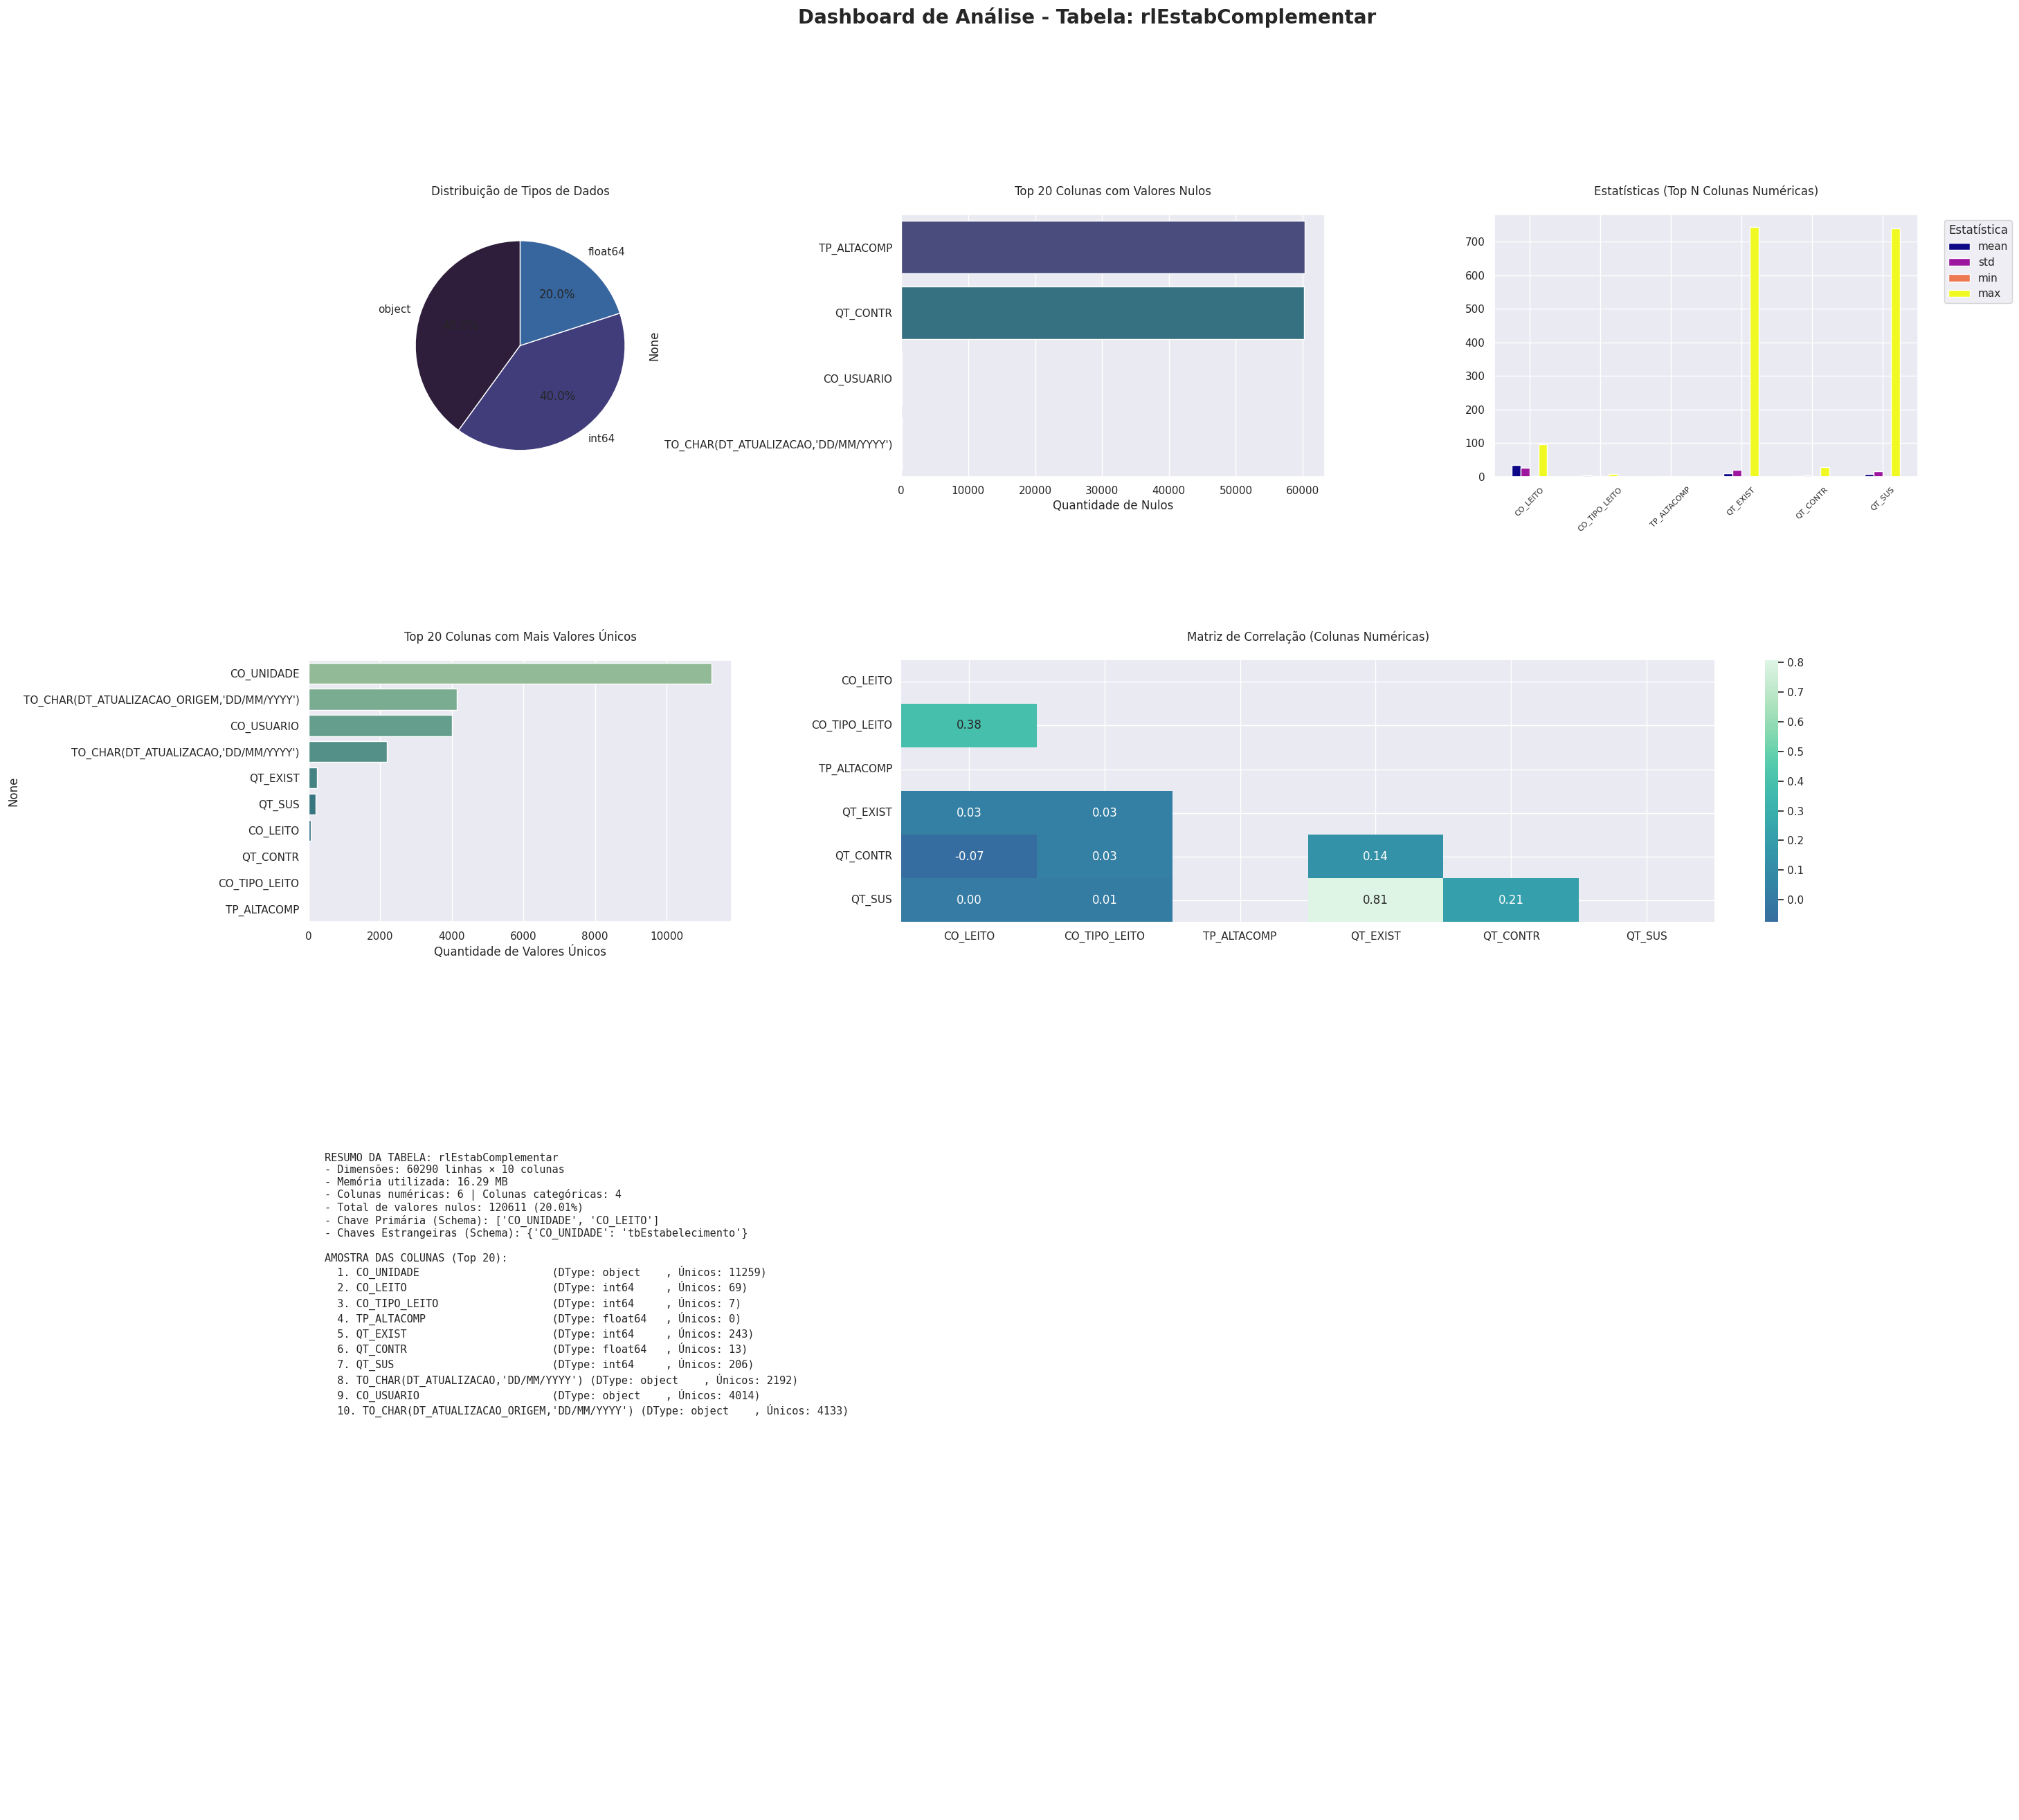

In [12]:
# Para analisar uma tabela específica e visualizar no notebook:
analisar_tabela('rlEstabComplementar')

## Análise das Tabelas Individualmente

### RL_ESTAB_COMPLEMENTAR - Leitos Hospitalares
- Chaves Primárias: CO_UNIDADE, CO_LEITO
- Sem uso: TP_ALTACOMP, QT_CONTR

### TB_ESTABELECIMENTO - Estabelecimentos
- Chaves Primárias: CO_UNIDADE, CO_LEITO
- Chaves Estrangeiras: CO_UNIDADE -> TB_ESTABELECIMENTO
- Sem uso: TP_ALTACOMP, QT_CONTR

### RL_ESTAB_ATEND_PREST_CONV - Atendimento prestado por unidade
- Chaves Estrangeiras: CO_UNIDADE -> TB_ESTABELECIMENTO

### RL_ESTAB_PROG_FUNDO - Gestão de Atividades / Nível de Atenção
- Chaves Estrangeiras: CO_UNIDADE -> TB_ESTABELECIMENTO

### RL_ESTAB_COLETA_SEL_REJEITO - Coleta Seletiva de Rejeitos
- Chaves Estrangeiras: CO_UNIDADE -> TB_ESTABELECIMENTO

### RL_ESTAB_SERVICO_APOIO - Serviços de Apoio
- Chaves Estrangeiras: CO_UNIDADE -> TB_ESTABELECIMENTO

### Tabelas de Tratamentos
- Diálise, Quimioterapia/Radioterapia, Hemoterapia
- Chaves Estrangeiras: CO_UNIDADE -> TB_ESTABELECIMENTO

# Tabelas legais de usar
- RL_ESTAB_COMPLEMENTAR - LEITOS HOSPITALARES
- TB_ESTABELECIMENTO - ESTABELECIMENTOS DE SAÚDE
- RL_ESTAB_ATEND_PREST_CONV - ATENDIMENTO PRESTADO P/ UNIDADE
- RL_ESTAB_PROG_FUNDO - GESTÃO DE ATIVIDADES / NÍVEL DE ATENÇÃO
- RL_ESTAB_COLETA_SEL_REJEITO - COLETA SELETIVA DE REJEITOS
- RL_ESTAB_SERVICO_APOIO - SERVIÇOS DE APOIO
- TB_DIALISE - DIÁLISE
- TB_QUIMIO_RADIO - QUIMIOTERAPIA E RADIOTERAPIA
- RL_ESTAB_COMISSAO_OUTRO - COMISSÕES
- RL_ESTAB_INST_FISI_ASSIST - INSTALAÇÕES FÍSICAS PARA ASSISTÊNCIA
- TB_SERVICO_REFERENCIADO - SERVIÇO REFERENCIADO
- RL_ESTAB_EQUIPAMENTO - EQUIPAMENTOS
- TB_HEMOTERAPIA - HEMOTERAPIA
- RL_ESTAB_SERV_CLASS - SERVIÇO ESPECIALIZADO / CLASSIFICAÇÃO
- RL_COOPERATIVA - COOPERATIVAS
- TB_EQUIPE - EQUIPES
- TB_RESIDENCIA_MED - RESIDÊNCIA TERAPÊUTICA
- TB_SEGMENTO - SEGMENTOS
- TB_AREA - ÁREAS DAS EQUIPES

In [ ]:
from typing import Set

def _find_set_differences(set1: Set, set2: Set) -> tuple[int, int]:
    """Calcula o número de itens adicionados e removidos entre dois sets."""
    added = len(set2 - set1)
    removed = len(set1 - set2)
    return added, removed

def comparar_periodos(
    periodo_anterior: str,
    periodo_atual: str,
    diretorio_base: Path = DATA_DIR
) -> pd.DataFrame:
    """
    Compara as tabelas do CNES entre dois períodos diferentes.

    Args:
        periodo_anterior: O período mais antigo (ex: '202506').
        periodo_atual: O período mais recente (ex: '202507').
        diretorio_base: O caminho para o diretório com os dados do CNES.

    Returns:
        Um DataFrame do Pandas com o resumo das comparações.
    """
    print(f"--- Comparando Período {periodo_anterior} com {periodo_atual} ---")

    # Carrega os dataframes para cada período
    print("\nCarregando dados do período anterior...")
    dfs_anterior = processar_tabelas(diretorio_base, periodo_anterior)

    print("\nCarregando dados do período atual...")
    dfs_atual = processar_tabelas(diretorio_base, periodo_atual)

    # Identifica tabelas comuns aos dois períodos
    tabelas_comuns = sorted(list(set(dfs_anterior.keys()) & set(dfs_atual.keys())))
    print(f"\nEncontradas {len(tabelas_comuns)} tabelas em comum para comparação.")

    resultados = []

    for nome_tabela in tabelas_comuns:
        df1 = dfs_anterior[nome_tabela]
        df2 = dfs_atual[nome_tabela]

        # Comparação de colunas
        colunas1 = set(df1.columns)
        colunas2 = set(df2.columns)
        colunas_adicionadas = list(colunas2 - colunas1)
        colunas_removidas = list(colunas1 - colunas2)

        # Comparação de linhas baseada na chave primária (se definida no schema)
        linhas_adicionadas, linhas_removidas = pd.NA, pd.NA
        schema_info = SCHEMA_CNES.get(nome_tabela)

        if schema_info and schema_info.get('pkey'):
            pkey = schema_info['pkey']
            # Garante que pkey seja sempre uma lista
            pkey_list = [pkey] if isinstance(pkey, str) else pkey

            if all(col in df1.columns and col in df2.columns for col in pkey_list):
                # Converte chaves para tuplas para poder usar 'set' em chaves compostas
                ids1 = set(df1[pkey_list].itertuples(index=False, name=None))
                ids2 = set(df2[pkey_list].itertuples(index=False, name=None))
                linhas_adicionadas, linhas_removidas = _find_set_differences(ids1, ids2)
            else:
                print(f"⚠️  Chave primária {pkey_list} não encontrada em ambas as DFs da tabela {nome_tabela}.")


        resultados.append({
            'Tabela': nome_tabela,
            f'Linhas_{periodo_anterior}': len(df1),
            f'Linhas_{periodo_atual}': len(df2),
            'Diff_Linhas': len(df2) - len(df1),
            'Linhas_Adicionadas': linhas_adicionadas,
            'Linhas_Removidas': linhas_removidas,
            'Colunas_Adicionadas': colunas_adicionadas if colunas_adicionadas else "Nenhuma",
            'Colunas_Removidas': colunas_removidas if colunas_removidas else "Nenhuma"
        })

    print("\nComparação concluída.")
    return pd.DataFrame(resultados)

# --- Exemplo de Uso ---
# Certifique-se de que os dados para '202506' também estão na pasta 'CNES/'
df_comparacao = comparar_periodos(periodo_anterior='202506', periodo_atual='202507')

# Exibe o resultado da comparação de forma organizada
display(df_comparacao.sort_values(by='Diff_Linhas', ascending=False).reset_index(drop=True))

--- Comparando Período 202506 com 202507 ---

Carregando dados do período anterior...
Encontrados 108 arquivos para o período 202506.

✅ Tabela 'tbSubtipoInstalacao' carregada: (7, 2)
✅ Tabela 'tbMotivoDesativacao' carregada: (14, 2)
✅ Tabela 'tbServicoEspecializado' carregada: (72, 2)
✅ Tabela 'tbTpModVinculo' carregada: (39, 3)
✅ Tabela 'tbGrupoEquipe' carregada: (28, 2)
✅ Tabela 'tbInstituicaoAvaliadora' carregada: (7, 2)
✅ Tabela 'tbNaturezaJuridica' carregada: (100, 2)
✅ Tabela 'tbTipoUnidade' carregada: (39, 2)
✅ Tabela 'tbTipoServicoReferenciado' carregada: (30, 3)
✅ Tabela 'tbColetaSeletivaRejeito' carregada: (5, 2)
✅ Tabela 'tbServicoApoio' carregada: (12, 2)
✅ Tabela 'rlEstabRegimeRes' carregada: (108, 21)
⚠️  Tabela 'tbEquipeAtendCompl' (tbEquipeAtendCompl202506.csv) está vazia.
✅ Tabela 'rlAtividadeObrigatoria' carregada: (14, 2)
✅ Tabela 'tbConvenio' carregada: (7, 2)
✅ Tabela 'rlEstabEquipeProf' carregada: (833269, 21)
✅ Tabela 'tbEquipamento' carregada: (112, 3)
✅ Tabela